In [22]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [23]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [24]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt
from model.linear_model import LinearModel

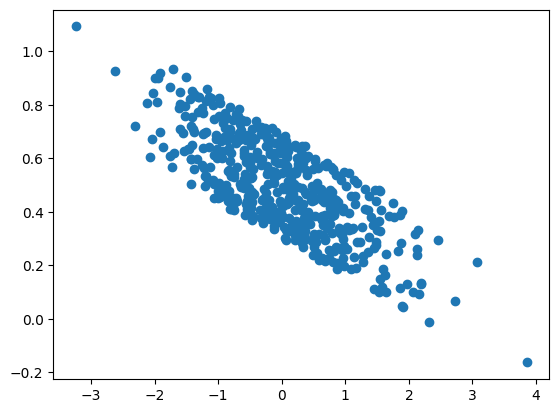

In [25]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [26]:
# Loading data
# loaded_data = np.load(f'data/linear_data/linear_data_A.npz')

# X = loaded_data['X_data']
# y = loaded_data['y_data']
# W = loaded_data['W_data']

# # Show the size of data
# print(f"X size : {X.shape}, y size : {y.shape}")

# # Make sure size and dim correct.
# size = X.shape[0]
# dim = X.shape[1]-1

def load_data(tgt_dataset):
    loaded_data = np.load(f'data/linear_data/linear_data_{tgt_dataset}.npz')
    X = loaded_data['X_data']
    y = loaded_data['y_data']
    W = loaded_data['W_data']

    # Show the size of data
    print(f"X size : {X.shape}, y size : {y.shape}")

    # Make sure size and dim correct.
    size = X.shape[0]
    dim = X.shape[1]-1

    return X, y, W, size, dim

# RANDOM SEED DECLEARED HERE
seed = 42 # do not change the seed
np.random.seed(seed)


def train_model(tgt_dataset = "A", lr = 0.01, n_iteration = 500, val_ratio = 0.2, draw_scatter = False):
    # read data
    X, y, W, size, dim = load_data(tgt_dataset)

    # Setting loss function and gradient. 
    loss_fn = MSE
    grad_fn = MSE_grad
    # split dataset into train and validation dataset
    X_train, y_train, X_val, y_val = get_train_val(X, y)

    # set model and start training
    model = LinearModel(dim, True, loss_fn, grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=n_iteration, val_ratio=val_ratio)

    # evaluate the model
    y_val_pred = model.predict(X_val)
    evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title=f'Linear Regression Evaluation on dataset {tgt_dataset} dataset, lr={lr}')

    # draw scatter plot if needed
    if (draw_scatter):
        plt.figure(figsize=(5, 3))
        plt.scatter(X_val[:,1],y_val)
        plt.plot(X_val[:,1],y_val_pred)
        plt.show()

### Linear dataset A
#### lr = 0.1

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


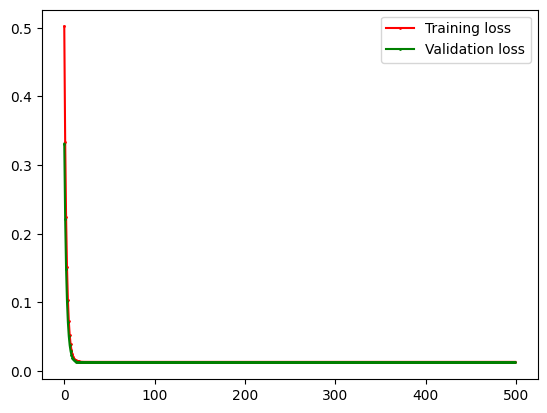

=== Linear Regression Evaluation on dataset A dataset, lr=0.1 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


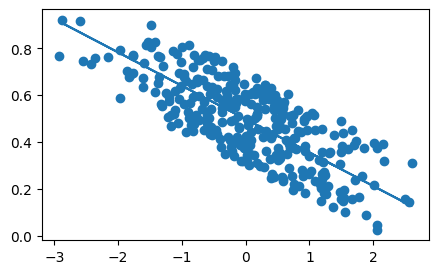

In [27]:
train_model(tgt_dataset="A",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.2238966593659602, Val loss:0.22227217013685485
100. Training loss: 0.04473791353662416, Val loss:0.043506871320832516
150. Training loss: 0.018083051477028687, Val loss:0.0170799487077392
200. Training loss: 0.014116985551358617, Val loss:0.013210362684918413
250. Training loss: 0.013526808616498798, Val loss:0.012658557107672769
300. Training loss: 0.013438979611857652, Val loss:0.012585780449882416
350. Training loss: 0.013425908200894933, Val loss:0.01257859777405428
400. Training loss: 0.013423962698572107, Val loss:0.012578954541903343
450. Training loss: 0.013423673122704472, Val loss:0.012579564566392844
500. Training loss: 0.013423630019323562, Val loss:0.012579872725242275


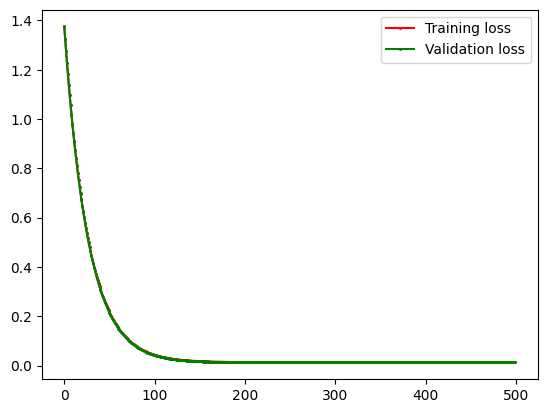

=== Linear Regression Evaluation on dataset A dataset, lr=0.01 ===
MSE       : 0.0134
MAE       : 0.1009
RMSE      : 0.1156
R-squared : 0.5690


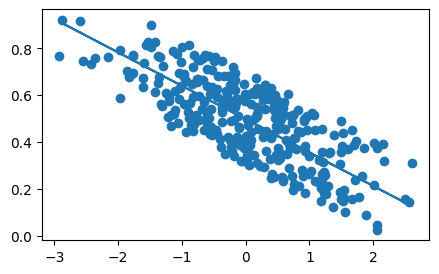

In [28]:
train_model(tgt_dataset="A",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.8073193599304311, Val loss:0.8241529476258102
100. Training loss: 0.6707081465060073, Val loss:0.6842801553483973
150. Training loss: 0.5576046128976588, Val loss:0.5684953729365146
200. Training loss: 0.4639636171949625, Val loss:0.4726520096184923
250. Training loss: 0.38643609623660413, Val loss:0.39331712931125573
300. Training loss: 0.3222492857920509, Val loss:0.3276486400150124
350. Training loss: 0.2691075522448654, Val loss:0.27329361603417657
400. Training loss: 0.22511028898031427, Val loss:0.22830411667665362
450. Training loss: 0.18868394100881886, Val loss:0.19106749078309526
500. Training loss: 0.1585257266607596, Val loss:0.16024867447531232


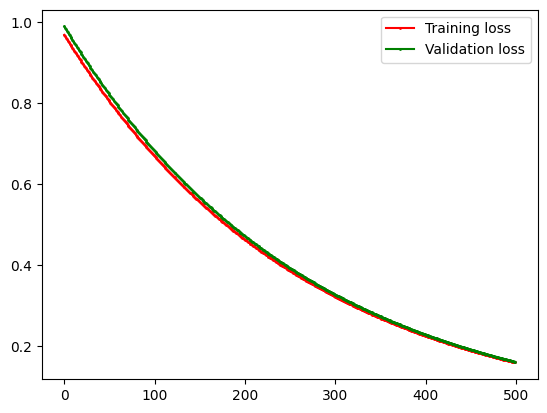

=== Linear Regression Evaluation on dataset A dataset, lr=0.001 ===
MSE       : 0.1563
MAE       : 0.3205
RMSE      : 0.3953
R-squared : -4.0433


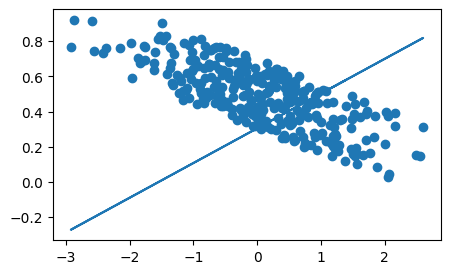

In [29]:
train_model(tgt_dataset="A",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### Linear dataset B
#### lr = 0.1

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.21477796066883237, Val loss:0.20128109890861168
100. Training loss: 0.2147779596957941, Val loss:0.20128143543167104
150. Training loss: 0.21477795969579408, Val loss:0.2012814354408099
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


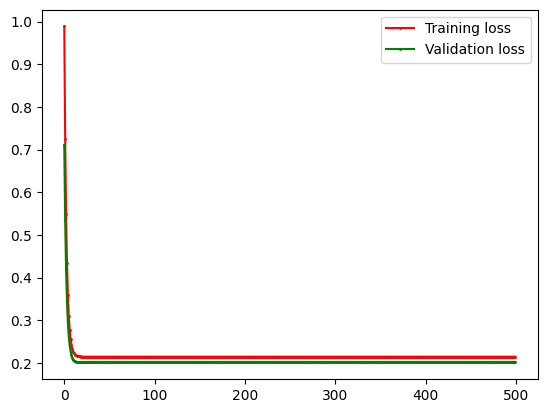

=== Linear Regression Evaluation on dataset B dataset, lr=0.1 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


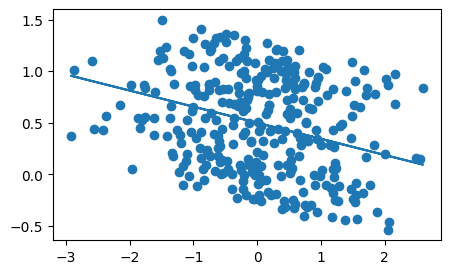

In [30]:
train_model(tgt_dataset="B",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.26464909148597293, Val loss:0.2422801458760765
100. Training loss: 0.2219683105059097, Val loss:0.20577799418047066
150. Training loss: 0.21581843751586055, Val loss:0.20140923616105857
200. Training loss: 0.2149290220959978, Val loss:0.2011069160516648
250. Training loss: 0.2147999577139333, Val loss:0.2011846943897838
300. Training loss: 0.21478117175217534, Val loss:0.2012409298478433
350. Training loss: 0.21477842984046402, Val loss:0.20126573660259128
400. Training loss: 0.21477802865836887, Val loss:0.2012755087480249
450. Training loss: 0.21477796983077477, Val loss:0.20127921816253902
500. Training loss: 0.21477796118777429, Val loss:0.2012806081249538


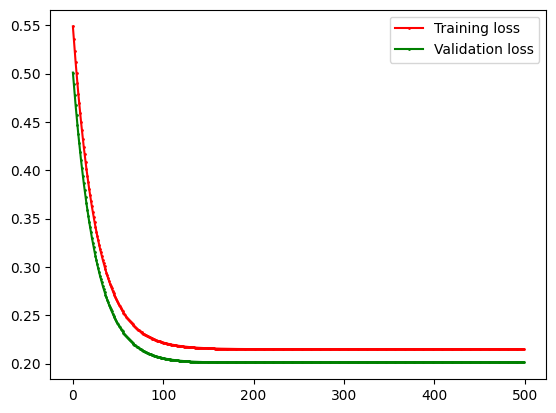

=== Linear Regression Evaluation on dataset B dataset, lr=0.01 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


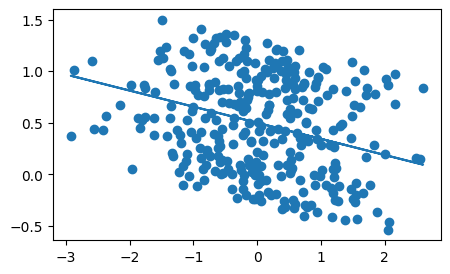

In [31]:
train_model(tgt_dataset="B",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (1600, 2), y size : (1600,)
50. Training loss: 0.4913616832965254, Val loss:0.4572827778647196
100. Training loss: 0.44292661922309207, Val loss:0.41121597248915004
150. Training loss: 0.4029811292093254, Val loss:0.3733384706417341
200. Training loss: 0.37003579319083046, Val loss:0.34220298454304565
250. Training loss: 0.34286274783774906, Val loss:0.31661733363331457
300. Training loss: 0.3204497092307371, Val loss:0.2955995185634799
350. Training loss: 0.30196208578201933, Val loss:0.2783407071326719
400. Training loss: 0.28671175635065316, Val loss:0.2641747380515127
450. Training loss: 0.2741313397820739, Val loss:0.25255299426187505
500. Training loss: 0.26375298902633815, Val loss:0.2430236999969285


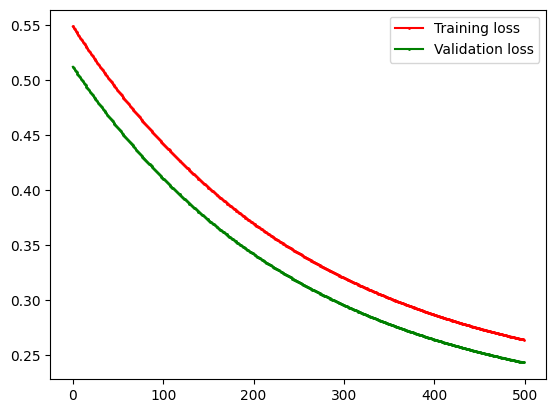

=== Linear Regression Evaluation on dataset B dataset, lr=0.001 ===
MSE       : 0.2483
MAE       : 0.4229
RMSE      : 0.4983
R-squared : -0.1098


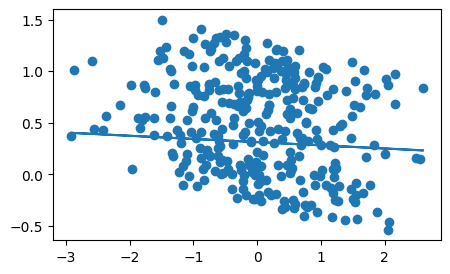

In [32]:
train_model(tgt_dataset="B",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### Linear dataset C
#### lr = 0.1

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.013181897126955286, Val loss:0.0137716930210076
100. Training loss: 0.013181896123422132, Val loss:0.013771595670608972
150. Training loss: 0.013181896123422132, Val loss:0.013771595669175329
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175313


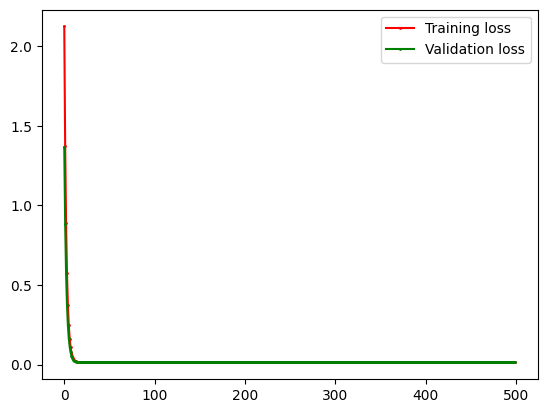

=== Linear Regression Evaluation on dataset C dataset, lr=0.1 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954


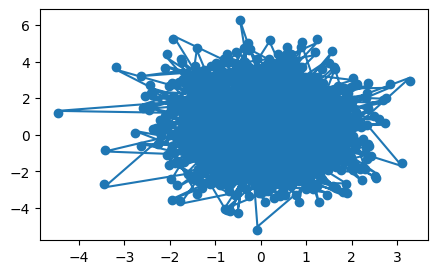

In [33]:
train_model(tgt_dataset="C",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.5063490066478714, Val loss:0.500972111616331
100. Training loss: 0.0789533188002609, Val loss:0.07929059516457253
150. Training loss: 0.02199073230056018, Val loss:0.022690085638355034
200. Training loss: 0.014366367675799106, Val loss:0.01501587662629197
250. Training loss: 0.013341756450857143, Val loss:0.013954904342443
300. Training loss: 0.013203545857360045, Val loss:0.013801844053448215
350. Training loss: 0.01318483748595336, Val loss:0.013777642414536379
400. Training loss: 0.01318229691715433, Val loss:0.01377311519601864
450. Training loss: 0.013181950883859381, Val loss:0.013772053692444709
500. Training loss: 0.013181903623910099, Val loss:0.013771748696472125


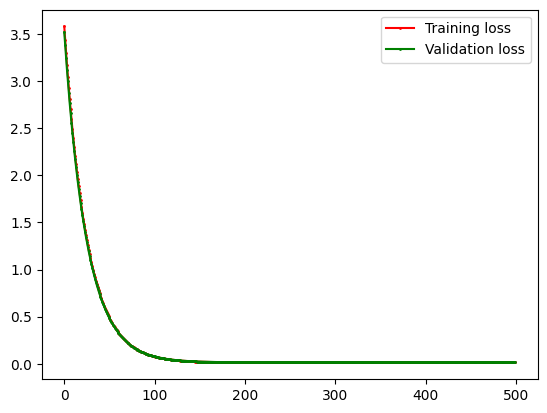

=== Linear Regression Evaluation on dataset C dataset, lr=0.01 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954


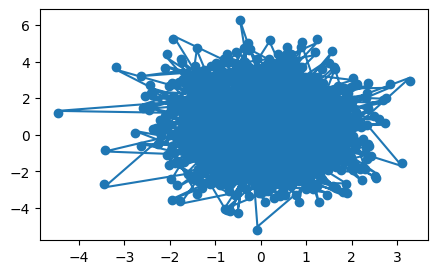

In [34]:
train_model(tgt_dataset="C",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (8000, 6), y size : (8000,)
50. Training loss: 2.2017451404642507, Val loss:2.1960124930846896
100. Training loss: 1.7998164816338846, Val loss:1.7966940168478416
150. Training loss: 1.471798919620354, Val loss:1.4705846498021669
200. Training loss: 1.204083036407607, Val loss:1.2042408378797262
250. Training loss: 0.9855686166698512, Val loss:0.9866913128789381
300. Training loss: 0.8072014207162119, Val loss:0.8089818094140864
350. Training loss: 0.6615955839876155, Val loss:0.663803735694145
400. Training loss: 0.5427257951776886, Val loss:0.5451912970717977
450. Training loss: 0.4456763418738028, Val loss:0.44827443701938263
500. Training loss: 0.3664365045400644, Val loss:0.3690772954522724


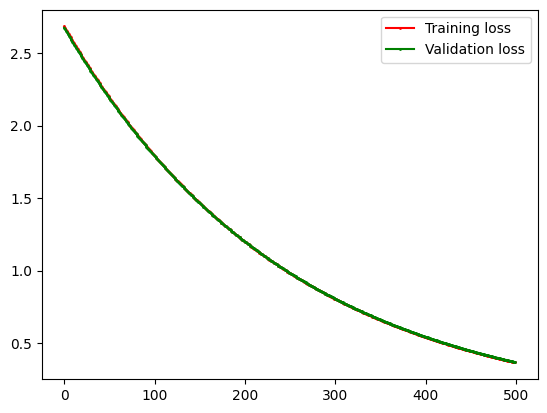

=== Linear Regression Evaluation on dataset C dataset, lr=0.001 ===
MSE       : 0.3455
MAE       : 0.4732
RMSE      : 0.5878
R-squared : 0.8782


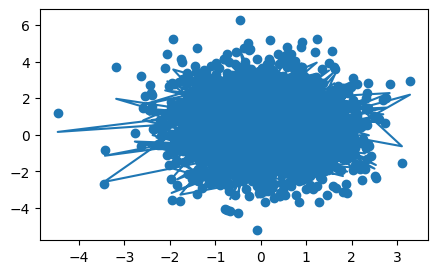

In [35]:
train_model(tgt_dataset="C",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

### Linear dataset D
#### lr = 0.1

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.08238685189267728, Val loss:0.08607272912905757
100. Training loss: 0.08238685077138833, Val loss:0.08607247293613877
150. Training loss: 0.08238685077138831, Val loss:0.08607247293234575
200. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
250. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
300. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
350. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
400. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
450. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
500. Training loss: 0.08238685077138833, Val loss:0.0860724729323457


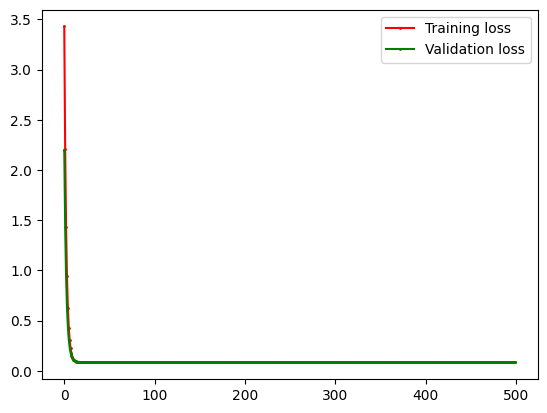

=== Linear Regression Evaluation on dataset D dataset, lr=0.1 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


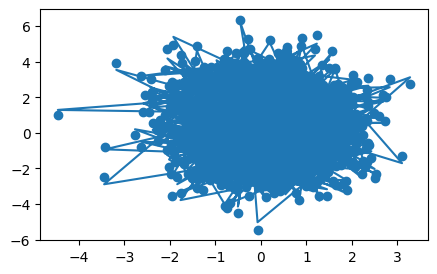

In [36]:
train_model(tgt_dataset="D",lr=0.1,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.01

X size : (8000, 6), y size : (8000,)
50. Training loss: 0.3577247184227582, Val loss:0.35739331914865186
100. Training loss: 0.11787423485933952, Val loss:0.12247259865689726
150. Training loss: 0.08699180403420656, Val loss:0.09126436160806282
200. Training loss: 0.08298840967382744, Val loss:0.08691284885403175
250. Training loss: 0.08246594719129074, Val loss:0.08624033011324964
300. Training loss: 0.08239731614060111, Val loss:0.08611515192706332
350. Training loss: 0.08238824373222911, Val loss:0.08608548727511352
400. Training loss: 0.08238703721926029, Val loss:0.08607684832316179
450. Training loss: 0.08238687585809601, Val loss:0.08607400887132355
500. Training loss: 0.08238685416313203, Val loss:0.08607302181781548


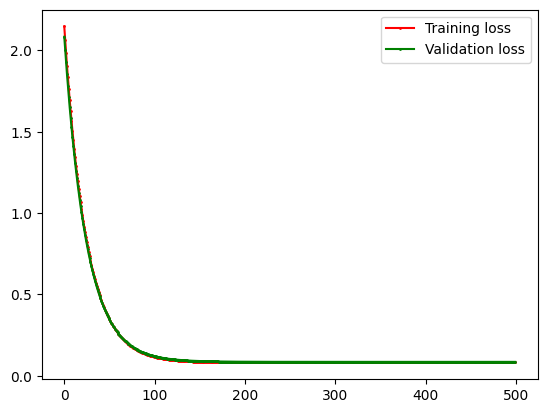

=== Linear Regression Evaluation on dataset D dataset, lr=0.01 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


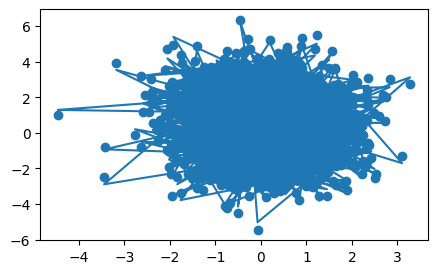

In [37]:
train_model(tgt_dataset="D",lr=0.01,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

#### lr = 0.001

X size : (8000, 6), y size : (8000,)
50. Training loss: 2.977842091849677, Val loss:2.991178630940393
100. Training loss: 2.4530500271915923, Val loss:2.466794666070195
150. Training loss: 2.0235225451749654, Val loss:2.03729485416881
200. Training loss: 1.6719392794934964, Val loss:1.685475644831643
250. Training loss: 1.3841339239972679, Val loss:1.397258335010949
300. Training loss: 1.1485189592797664, Val loss:1.161120508291243
350. Training loss: 0.9556154719214218, Val loss:0.9676310925714681
400. Training loss: 0.7976688370395155, Val loss:0.8090701216162944
450. Training loss: 0.6683345589051146, Val loss:0.679117744104588
500. Training loss: 0.562421441618319, Val loss:0.572599848709096


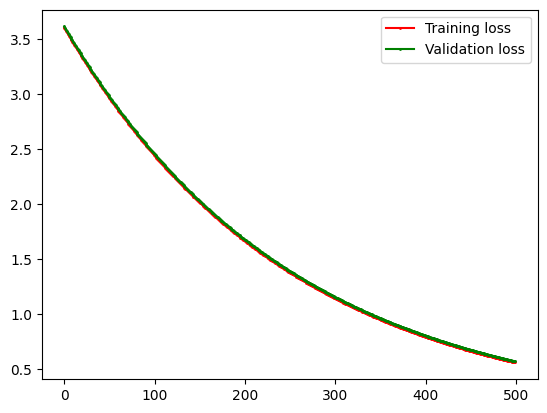

=== Linear Regression Evaluation on dataset D dataset, lr=0.001 ===
MSE       : 0.5738
MAE       : 0.6142
RMSE      : 0.7575
R-squared : 0.8022


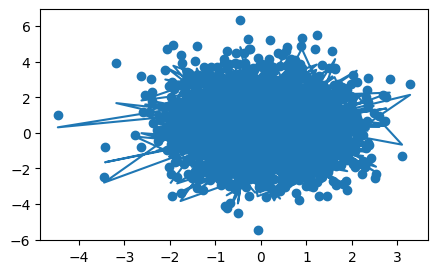

In [38]:
train_model(tgt_dataset="D",lr=0.001,n_iteration = 500,val_ratio=0.2,draw_scatter=True)

In [39]:
# # Train the model
# from model.linear_model import LinearModel

# seed = 42 # do not change the seed
# np.random.seed(seed)

# # Setting loss function and gradient. 
# loss_fn = MSE
# grad_fn = MSE_grad

# # Split dataset to train dataset and validation dataset
# X_train,y_train,X_val,y_val = get_train_val(X,y)

# # Setting model and starting training
# model = LinearModel(dim,True,loss_fn,grad_fn)
# model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [40]:
# # Get the Prediction
# y_val_pred = model.predict(X_val)

In [41]:
# # Evaluation 
# # Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
# evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

In [42]:
# # Plot
# plt.scatter(X_val[:,1],y_val)
# plt.plot(X_val[:,1],y_val_pred)
# plt.show()